# Cheap selection filters on BDD100K

Compare the four stock filters documented in [Phase 1](../docs/experiments/phase1/index.md): accept-all (B-floor), uniform reservoir replay (B1), within-batch semantic deduplication, and high-loss selection (B3).

This is a bounded, exploratory MAE experiment, not a degradation gate or a new P1.2 result. The current P1.2 verdict found no adaptation benefit for the tested TinyViT vehicles. A small randomly initialized MAE makes this notebook runnable without downloading weights; it does not establish the value of continual adaptation.

Each arm gets the same initialization, regime-ordered stream and held-out scene probes. Attributes order the stream and label evaluation only; filters receive no labels. These are attribute blocks over still images, not temporal video order. Replay adds training examples, while admission filters remove them: report training exposure and wall time alongside quality rather than calling this compute-matched.

Use the project's Python environment as the notebook kernel. The notebook also needs pandas, matplotlib and IPython (available in the temporary validation environment via uv run --with pandas --with matplotlib --with ipython).


In [14]:
import sys
from pathlib import Path

# VS Code can start this notebook inside the package directory.
repo_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "cafl4ds/configs").is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Open this notebook from within the cafl4ds repository.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [15]:
import random
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra.utils import instantiate
from IPython.display import display as show
from loguru import logger
from omegaconf import OmegaConf

from cafl4ds.data.regime import RegimeStream
from cafl4ds.data.streams import EvalSet, EvalSets, StreamBatch
from cafl4ds.filters.base import Filter, FilterContext
from cafl4ds.harness import run_stream_arm
from cafl4ds.jsonio import dumps_valid
from cafl4ds.monitor import HealthMonitor

## What question are we asking?

Imagine a camera sending a long sequence of road images. Training on every image may spend work on very similar scenes. A filter decides what reaches the next learning update. We want to see whether it can reduce that work while preserving useful image features.

| Filter | What happens to one incoming batch? | What to watch |
| --- | --- | --- |
| Accept-all | Every incoming image reaches training. | The reference for the cost and quality of the other filters. |
| Reservoir replay | All incoming images are used, plus a random sample of earlier images. The buffer stores at most 256 images with the stock config. | More training presentations may help preserve earlier information, but they cost extra work. |
| Semantic deduplication | The current model embeds the images. A greedy pass removes images whose cosine similarity to a kept image exceeds 0.9. | This only compares images within the current batch. An untrained model can consider different images similar and reject too much. |
| Loss gate | The current MAE scores reconstruction difficulty and keeps the half with the highest loss. | Difficulty is a heuristic, not a guarantee of usefulness. Scoring discarded images also costs time. |

The MAE learns by reconstructing hidden image patches. Scene labels never drive this learning or the filters. Separately, fixed held-out images test whether the learned features help distinguish scenes such as highway and city street.

**Read the figures in order:** check the available driving conditions, inspect how much data reaches training, then compare quality against the work spent. A filter that makes no updates may look stable simply because the model never changes.


## Settings

Change `bdd_root` to the dataset directory containing `images/100k` and `labels`. Set `images_dir` directly if your layout differs. BDD attribute JSON is required in addition to images; `labels_file` accepts a combined JSON file or a directory of per-image JSON records.

The source caches decoded float32 images in RAM. The default cap is deliberate: 2,000 images at 64 pixels require about 94 MiB for image tensors, before stream/evaluation copies. Removing the cap loads the full split. The cap uses the first attribute-valid records, so this pilot is not a representative full-dataset estimate. Expand the data and seeds before drawing conclusions.

CUDA is preferred. The setup checks that a small GPU operation works and falls back to CPU if CUDA is unavailable or fails that check. Set `prefer_cuda = False` to force CPU. An out-of-memory failure during training still stops the run: reduce `batch_size` or `img_size`, or force CPU, then rerun from Settings. This avoids silently mixing CPU and GPU timings in one comparison.


In [16]:
bdd_root = Path(r"D:\AI Proj\bdd100k_images_100k")
bdd_split = "train"
images_dir = bdd_root / "images" / "100k" / bdd_split
labels_file = bdd_root / "labels" / f"bdd100k_labels_images_{bdd_split}.json"

seeds = [13]  # Extend, e.g. [13, 42, 101], for replication.
img_size = 64
batch_size = 32
max_images = 2000
max_train_per_regime = 128
support_per_canary = 8
query_per_canary = 8
min_canary_count = 32
canary_seed = 0
eval_every = 5
prefer_cuda = True  # Set False to force CPU.
device = "cpu"
if prefer_cuda and torch.cuda.is_available():
    try:
        # Check a real allocation and operation, not just driver discovery.
        cuda_probe = torch.ones(8, device="cuda")
        _ = (cuda_probe * cuda_probe).sum().item()
        torch.cuda.synchronize()
        del cuda_probe
        device = "cuda"
    except RuntimeError as exc:
        logger.warning("CUDA startup failed; using CPU: {}", exc)
logger.info("Compute: {}", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")
filter_names = ["accept_all", "reservoir", "dedup", "loss_gate"]

method_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.ssl.factory.build_mae",
        "encoder": {
            "_target_": "cafl4ds.models.vit.TinyViTEncoder",
            "img_size": img_size,
            "patch_size": 8,
            "embed_dim": 64,
            "depth": 2,
            "num_heads": 4,
            "mlp_ratio": 2.0,
        },
        "decoder_dim": 32,
        "decoder_depth": 1,
        "decoder_heads": 4,
        "mask_ratio": 0.75,
    }
)
optimizer_cfg = OmegaConf.create({"_target_": "torch.optim.AdamW", "lr": 1e-4, "weight_decay": 1e-4})
stream_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.data.regime.RegimeStream",
        "batch_size": batch_size,
        "support_per_canary": support_per_canary,
        "query_per_canary": query_per_canary,
        "era_query_per_cell": 0,
        "max_train_per_regime": max_train_per_regime,
        "canary_seed": canary_seed,
    }
)
source_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.data.attributes.BDD100KSource",
        "bdd_root": str(bdd_root),
        "split": bdd_split,
        "images_dir": str(images_dir),
        "labels_file": str(labels_file),
        "img_size": img_size,
        "max_images": max_images,
        "min_canary_count": min_canary_count,
    }
)
logger.info("Device: {}; filters: {}", device, filter_names)

2026-09-28 21:36:25.099 | INFO     | __main__:<module>:28 - Compute: NVIDIA GeForce GTX 1660 Ti
2026-09-28 21:36:25.101 | INFO     | __main__:<module>:73 - Device: cuda; filters: ['accept_all', 'reservoir', 'dedup', 'loss_gate']


In [17]:
if not images_dir.is_dir():
    raise FileNotFoundError(f"Set bdd_root/images_dir to your BDD image folder: {images_dir}")
if not labels_file.exists():
    raise FileNotFoundError(f"Set labels_file to the BDD attributes JSON or per-image JSON directory: {labels_file}")
source = instantiate(source_cfg)
preview = instantiate(stream_cfg, source=source, seed=seeds[0])
if len(preview) == 0:
    raise ValueError("No training batches remain; increase max_images or reduce probe reservations.")
logger.info("{} batches; {} regimes; {} scene classes", len(preview), preview.num_eras, len(preview.canary_names))
show(pd.DataFrame([{"era": k, "regime": v} for k, v in preview.era_names.items()]))

2026-09-28 21:36:34.309 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['parking lot', 'tunnel']
2026-09-28 21:36:43.675 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 1984 images (train) at 64px over 17 regimes, 3 scenes
2026-09-28 21:36:44.116 | INFO     | __main__:<module>:9 - 38 batches; 17 regimes; 3 scene classes


,era,regime
0,0,daytime·clear
1,1,daytime·partly cloudy
2,2,daytime·overcast
3,3,daytime·rainy
4,4,daytime·snowy
5,5,daytime·foggy
6,6,dawn/dusk·clear
7,7,dawn/dusk·partly cloudy
8,8,dawn/dusk·overcast
9,9,dawn/dusk·rainy


## 1. What does this stream contain?

Each row below is a driving condition, defined by time of day and weather. The bars count actual training arrivals **after** held-out evaluation images and the per-condition cap have been removed. A short bar means less opportunity to learn that condition.

The bottom panel shows their order for the first seed. Long blocks create a changing diet: the model sees one condition for a while, then another. These are grouped still images, not consecutive frames from a drive. Other seeds shuffle within each condition and may change which capped images are used.


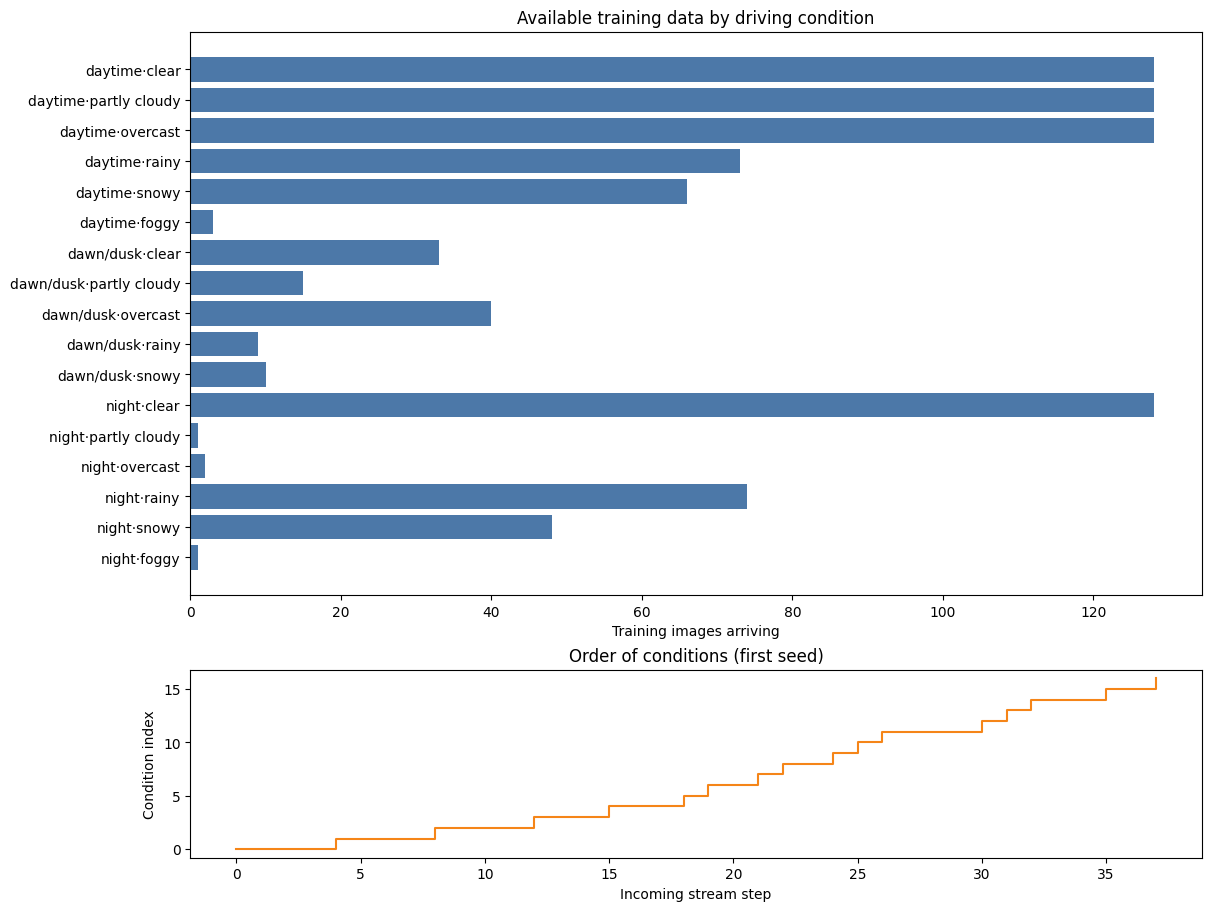

In [18]:
stream_rows = [{"step": batch.step, "era": batch.era, "images": len(batch.images)} for batch in preview]
stream_df = pd.DataFrame(stream_rows)
era_counts = stream_df.groupby("era")["images"].sum()
fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True)
axes[0].barh([preview.era_names[int(era)] for era in era_counts.index], era_counts.values, color="#4c78a8")
axes[0].invert_yaxis()
axes[0].set(xlabel="Training images arriving", title="Available training data by driving condition")
axes[1].step(stream_df["step"], stream_df["era"], where="post", color="#f58518")
axes[1].set(xlabel="Incoming stream step", ylabel="Condition index", title="Order of conditions (first seed)")
plt.show()
# Save this figure after the run creates its output folder.
stream_figure = fig

## Run the comparison

Filters are instantiated from the repository's Hydra configs, including their stock thresholds and buffer settings. Reservoir replay is composed through `CompositeSelector`, as required by the loop interface.

Counts distinguish stream arrivals from optimizer image presentations (including replay). The loop skips selected batches smaller than two; these are counted separately. A frozen initial reading supplies the B5 reference and anchors drift before the first update. Wall time includes filtering, training, monitoring and logging, but excludes dataset loading. Different filters consume different augmentation/masking random draws, even with the same seed.

Per-batch selection records are saved as `selection.csv` and individual arm files. They contain counts only, not labels or retained images. Training exposure counts repeat presentations of replayed images; it is not a count of unique images.


In [19]:
def seed_all(seed: int) -> None:
    """Reset model and augmentation RNGs for a paired arm."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def filter_config(name: str, seed: int) -> dict[str, Any]:
    """Resolve a stock filter config for this seed and batch size."""
    cfg = OmegaConf.create({"batch_size": batch_size, "seed": seed})
    cfg.selection = OmegaConf.load(repo_root / "cafl4ds/configs/filter" / f"{name}.yaml")
    return OmegaConf.to_container(cfg.selection, resolve=True)


class RecordingFilter(Filter):
    """Count optimizer presentations separately from incoming frames."""

    def __init__(self, wrapped: Filter) -> None:
        """Wrap a selector with exposure counters."""
        self.wrapped = wrapped
        self.arrivals = 0
        self.train_presentations = 0
        self.skipped_batches = 0
        self.batch_records: list[dict[str, int]] = []

    def select(self, batch: StreamBatch, ctx: FilterContext) -> torch.Tensor:
        """Select images and count batches eligible for optimization."""
        self.arrivals += len(batch.images)
        selected = self.wrapped.select(batch, ctx)
        if len(selected) < 2:
            self.skipped_batches += 1
        else:
            self.train_presentations += len(selected)
        self.batch_records.append(
            {
                "step": batch.step,
                "era": batch.era,
                "arrivals": len(batch.images),
                "selected": len(selected),
                "trained": len(selected) if len(selected) >= 2 else 0,
                "skipped": int(len(selected) < 2),
            }
        )
        return selected

    def auxiliary_loss(self, images: torch.Tensor, ctx: FilterContext) -> torch.Tensor | None:
        """Delegate optional regularization to the selector."""
        return self.wrapped.auxiliary_loss(images, ctx)


def make_monitor(stream: RegimeStream) -> HealthMonitor:
    """Move held-out probes to the device and build a fresh monitor."""

    def move(part: EvalSet) -> EvalSet:
        return EvalSet(images=part.images.to(device), labels=part.labels.to(device))

    ev = stream.eval_sets
    eval_sets = EvalSets(
        probe_support=move(ev.probe_support),
        probe_query=move(ev.probe_query),
        per_era={k: move(v) for k, v in ev.per_era.items()},
    )
    return instantiate(
        {"_target_": "cafl4ds.monitor.HealthMonitor", "knn_k": 5, "run_alignment": False}, eval_sets=eval_sets
    )


def run_one(name: str, seed: int, output_dir: Path) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    """Run one paired arm and return summary and health records."""
    seed_all(seed)
    stream = instantiate(stream_cfg, source=source, seed=seed)
    method = instantiate(method_cfg).to(device)
    optimizer = instantiate(optimizer_cfg, params=method.parameters())
    selector = RecordingFilter(instantiate(filter_config(name, seed)))
    monitor = make_monitor(stream)
    initial = monitor.measure(method, -1)
    # Reset random draws after the common initial probe measurement.
    seed_all(seed)
    if device == "cuda":
        torch.cuda.synchronize()
    start = perf_counter()
    arm = run_stream_arm(
        name=f"{name}_seed{seed}",
        role="live",
        method=method,
        stream=stream,
        optimizer=optimizer,
        selection_filter=selector,
        monitor=monitor,
        out_dir=output_dir,
        eval_every=eval_every,
        device=device,
    )
    if device == "cuda":
        torch.cuda.synchronize()
    # Skipped updates can leave the loop without a terminal health record.
    terminal = monitor.measure(method, len(stream) - 1) if not arm.diverged else None
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - start
    final = terminal if terminal is not None else {k: float("nan") for k in initial}
    pd.DataFrame(selector.batch_records).assign(filter=name, seed=seed).to_csv(
        output_dir / f"{name}_seed{seed}_selection.csv", index=False
    )
    summary = {
        "filter": name,
        "seed": seed,
        "diverged": arm.diverged,
        "arrivals": selector.arrivals,
        "train_presentations": selector.train_presentations,
        "presentations_per_arrival": selector.train_presentations / max(1, selector.arrivals),
        "updates": len(arm.loss_records),
        "skipped_batches": selector.skipped_batches,
        "wall_seconds": elapsed,
        "device": device,
    }
    for metric in ["knn_acc", "linear_acc", "rankme", "cosine_drift"]:
        summary[f"initial_{metric}"] = initial[metric]
        summary[f"final_{metric}"] = final[metric]
        summary[f"delta_{metric}"] = final[metric] - initial[metric]
    records = [{"filter": name, "seed": seed, **initial}]
    records.extend({"filter": name, "seed": seed, **r} for r in arm.health)
    if terminal is not None and (not arm.health or arm.health[-1]["step"] != terminal["step"]):
        records.append({"filter": name, "seed": seed, **terminal})
    return summary, records

In [20]:
output_dir = (
    repo_root / "outputs" / "selection-filter-experiment" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
)
output_dir.mkdir(parents=True, exist_ok=False)
manifest = {
    "source": OmegaConf.to_container(source_cfg, resolve=True),
    "stream": OmegaConf.to_container(stream_cfg, resolve=True),
    "method": OmegaConf.to_container(method_cfg, resolve=True),
    "optimizer": OmegaConf.to_container(optimizer_cfg, resolve=True),
    "filters": {str(s): {n: filter_config(n, s) for n in filter_names} for s in seeds},
    "seeds": seeds,
    "device": device,
    "eval_every": eval_every,
    "torch_version": torch.__version__,
    "purpose": "exploratory cheap-filter comparison",
}
(output_dir / "config.json").write_text(dumps_valid(manifest), encoding="utf-8")
summaries, health_records = [], []
for seed in seeds:
    for name in filter_names:
        logger.info("Running {} with seed {}", name, seed)
        summary, records = run_one(name, seed, output_dir)
        summaries.append(summary)
        health_records.extend(records)
        # Save after every arm, preserving completed results if a later arm fails.
        pd.DataFrame(summaries).to_csv(output_dir / "summary.csv", index=False)
        pd.DataFrame(health_records).to_csv(output_dir / "health.csv", index=False)
summary_df = pd.DataFrame(summaries)
health_df = pd.DataFrame(health_records)
show(summary_df)
logger.info("Saved experiment to {}", output_dir)
selection_df = pd.concat(
    [pd.read_csv(output_dir / f"{name}_seed{seed}_selection.csv") for seed in seeds for name in filter_names],
    ignore_index=True,
)
selection_df.to_csv(output_dir / "selection.csv", index=False)

2026-09-28 21:36:44.341 | INFO     | __main__:<module>:21 - Running accept_all with seed 13
2026-09-28 21:36:44.431 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=0.0000 era=0.0000 loss=1.2801 rankme=3.9410 cka_drift=0.0002 cosine_drift=0.0027 knn_acc=0.2917 linear_acc=0.3333
2026-09-28 21:36:44.542 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=5.0000 era=1.0000 loss=1.2259 rankme=3.7544 cka_drift=0.0058 cosine_drift=0.0691 knn_acc=0.2917 linear_acc=0.3333
2026-09-28 21:36:44.639 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=10.0000 era=2.0000 loss=1.2010 rankme=3.5800 cka_drift=0.0122 cosine_drift=0.1641 knn_acc=0.2500 linear_acc=0.3750
2026-09-28 21:36:44.719 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=15.0000 era=4.0000 loss=1.1718 rankme=3.4490 cka_drift=0.0151 cosine_drift=0.2470 knn_acc=0.2500 linear_acc=0.3750
2026-09-28 21:36:44.769 | DEBUG    | cafl4ds.l

,filter,seed,diverged,arrivals,train_presentations,presentations_per_arrival,updates,skipped_batches,wall_seconds,device,...,delta_knn_acc,initial_linear_acc,final_linear_acc,delta_linear_acc,initial_rankme,final_rankme,delta_rankme,initial_cosine_drift,final_cosine_drift,delta_cosine_drift
0,accept_all,13,False,887,884,0.996618,35,3,0.663570,cuda,...,-0.083333,0.375,0.375000,0.000000,3.970032,3.192446,-0.777587,0.0,0.414485,0.414485
1,reservoir,13,False,887,2071,2.334837,38,0,0.722363,cuda,...,-0.083333,0.375,0.291667,-0.083333,3.970032,3.177737,-0.792296,0.0,0.449422,0.449422
2,dedup,13,False,887,18,0.020293,9,29,0.426590,cuda,...,0.000000,0.375,0.291667,-0.083333,3.970032,3.742444,-0.227588,0.0,0.094071,0.094071
3,loss_gate,13,False,887,440,0.496054,33,5,0.654919,cuda,...,-0.041667,0.375,0.250000,-0.125000,3.970032,3.216814,-0.753218,0.0,0.379951,0.379951


2026-09-28 21:36:46.998 | INFO     | __main__:<module>:31 - Saved experiment to c:\Users\muham\Documents\cafl4ds\outputs\selection-filter-experiment\20260928T193644334058Z


## 2. Does the representation change in a useful way?

These trajectories use the incoming stream step on the horizontal axis. That keeps filters aligned even when one skips learning updates. Dashed lines show the corresponding initial, frozen model score. Sparse monitoring means changes between measured points are unknown; connecting lines are visual guides.

| Measure | Plain-language meaning | How to read it |
| --- | --- | --- |
| kNN accuracy | A query image receives a scene prediction from nearby labeled support images in feature space. | Higher means these features group the held-out scenes more usefully. |
| Linear accuracy | A small linear classifier is fitted on frozen support features and evaluated on held-out queries. | Higher means scene information is easier to read from the features. The backbone does not learn from these labels. |
| RankMe | The effective number of directions occupied by the query features. | A fall means features concentrate in fewer directions. It is not automatically a loss of useful information. |
| Cosine drift | How much the query features change direction relative to their initial values. | Zero means no directional change. A rise can reflect learning or harmful change; use the accuracy panels to distinguish them. |

The probe set is intentionally small. With 8 queries per scene, one changed prediction can visibly move accuracy. One seed provides a pilot observation, not uncertainty estimates. A higher RankMe or lower drift alone does not identify a winning filter.


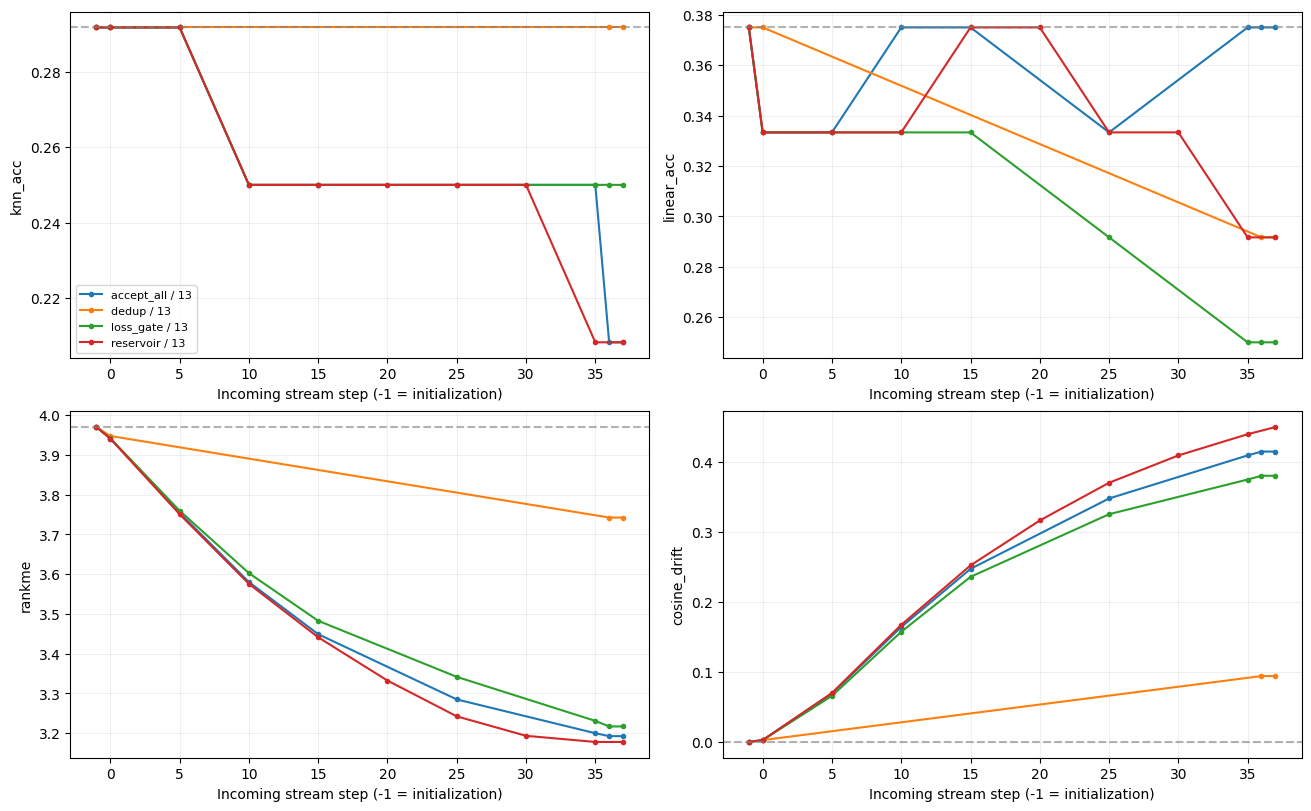

,filter,seed,diverged,updates,skipped_batches,presentations_per_arrival,wall_seconds,delta_knn_acc,delta_linear_acc
0,accept_all,13,False,35,3,0.996618,0.663570,-0.083333,0.000000
1,reservoir,13,False,38,0,2.334837,0.722363,-0.083333,-0.083333
2,dedup,13,False,9,29,0.020293,0.426590,0.000000,-0.083333
3,loss_gate,13,False,33,5,0.496054,0.654919,-0.041667,-0.125000


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, metric in zip(axes.flat, ["knn_acc", "linear_acc", "rankme", "cosine_drift"], strict=False):
    for (name, seed), rows in health_df.groupby(["filter", "seed"]):
        ordered_rows = rows.sort_values("step")
        ax.plot(ordered_rows["step"], ordered_rows[metric], marker=".", label=f"{name} / {seed}")
    for seed in seeds:
        base = summary_df[summary_df.seed == seed].iloc[0]
        ax.axhline(base[f"initial_{metric}"], color="gray", linestyle="--", alpha=0.6)
    ax.set(xlabel="Incoming stream step (-1 = initialization)", ylabel=metric)
    ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
fig.savefig(output_dir / "trajectories.png", dpi=150)
plt.show()
show(
    summary_df[
        [
            "filter",
            "seed",
            "diverged",
            "updates",
            "skipped_batches",
            "presentations_per_arrival",
            "wall_seconds",
            "delta_knn_acc",
            "delta_linear_acc",
        ]
    ]
)

## 3. What training work did each filter cause?

The left panel accumulates optimizer image presentations. A replayed image counts again each time it is used. The right panel counts batches that were too small to train on after selection. Each line represents one seed.

The heatmap breaks exposure down by the **arrival condition**. A value of 1 means one training presentation per incoming image; above 1 means replay added work; below 1 means admission filtering or skipped updates reduced it. Replay can contain images from older conditions, so a heatmap row does not describe the condition of every trained image.

Selected batches with fewer than two images contribute zero training presentations because the shared loop skips them. Check this before interpreting a flat health curve as stability.


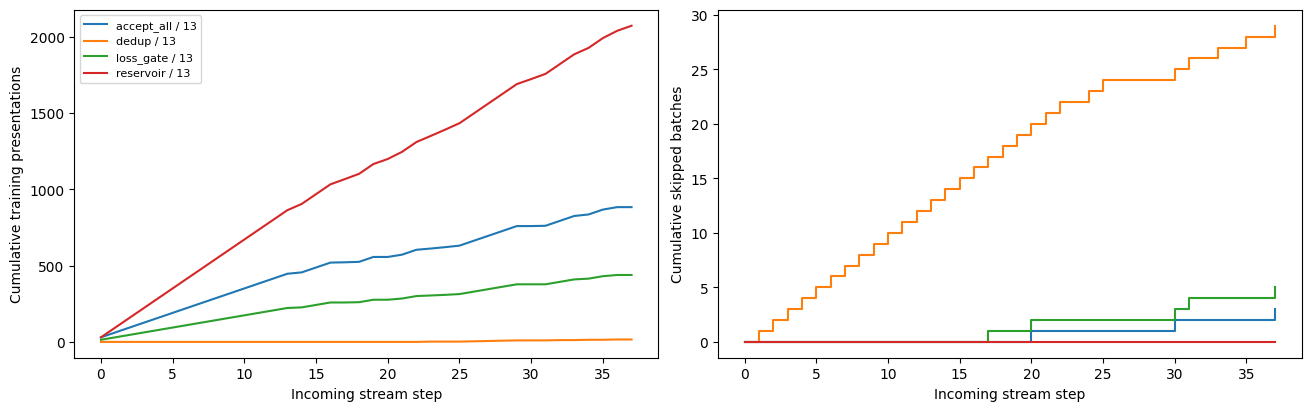

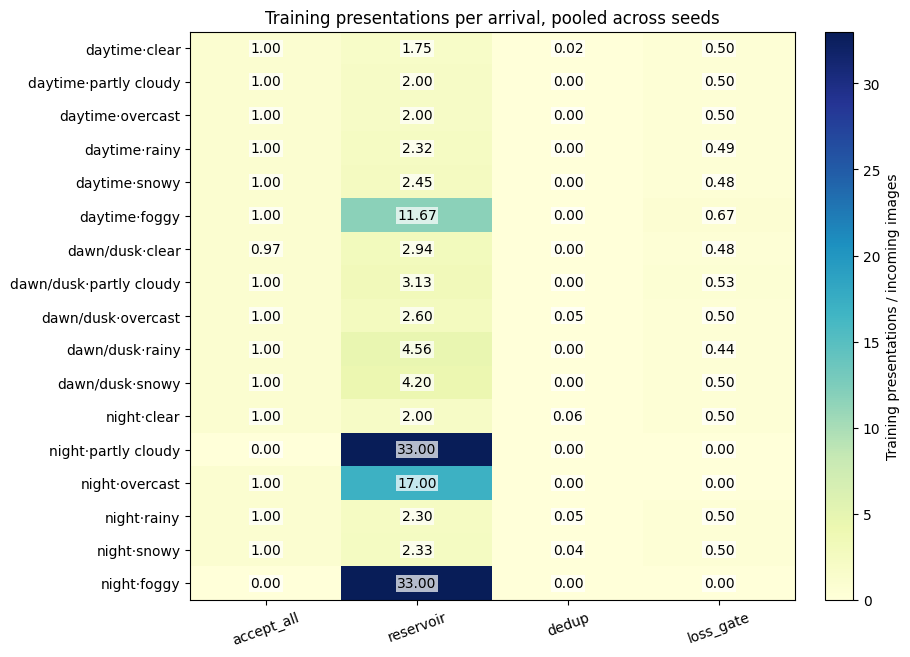

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for (name, seed), rows in selection_df.groupby(["filter", "seed"]):
    ordered = rows.sort_values("step")
    axes[0].plot(ordered["step"], ordered["trained"].cumsum(), label=f"{name} / {seed}")
    axes[1].step(ordered["step"], ordered["skipped"].cumsum(), where="post", label=f"{name} / {seed}")
axes[0].set(xlabel="Incoming stream step", ylabel="Cumulative training presentations")
axes[1].set(xlabel="Incoming stream step", ylabel="Cumulative skipped batches")
axes[0].legend(fontsize=8)
fig.savefig(output_dir / "training_exposure.png", dpi=150)
plt.show()

condition_totals = selection_df.groupby(["era", "filter"])[["trained", "arrivals"]].sum()
condition_totals["exposure"] = condition_totals["trained"] / condition_totals["arrivals"]
exposure_table = condition_totals["exposure"].unstack("filter").reindex(columns=filter_names)
fig, ax = plt.subplots(figsize=(9, max(4, len(exposure_table) * 0.38)), constrained_layout=True)
heat = ax.imshow(
    exposure_table.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=max(1.0, float(exposure_table.max().max()))
)
ax.set_xticks(range(len(filter_names)), filter_names, rotation=20)
ax.set_yticks(range(len(exposure_table)), [preview.era_names[int(e)] for e in exposure_table.index])
ax.set_title("Training presentations per arrival, pooled across seeds")
for row in range(len(exposure_table)):
    for col in range(len(filter_names)):
        value = exposure_table.iloc[row, col]
        if pd.notna(value):
            ax.text(
                col,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="black",
                bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 1},
            )
fig.colorbar(heat, ax=ax, label="Training presentations / incoming images")
fig.savefig(output_dir / "condition_exposure.png", dpi=150)
stream_figure.savefig(output_dir / "stream_composition.png", dpi=150)
plt.show()

## 4. Is the quality worth the work?

The scatter plot compares elapsed time with final linear accuracy. Moving left means less measured runtime; moving up means higher scene accuracy. Each point is a filter/seed run. Runtime includes filtering, optimization, monitoring, and logging, but excludes loading the dataset and the initial probe measurement. GPU warm-up and execution order can affect short runs, so these are exploratory timings.

The paired plot subtracts the **same seed's accept-all** accuracy from each filter's final accuracy. Above zero means the filter finished ahead of accept-all on this probe; below zero means it finished behind. Differences are in percentage points: 0.50 to 0.55 is a gain of 5 points. Lines connect seeds only to make their paired comparisons easier to follow.

With several seeds, inspect whether the direction repeats. With one seed, do not treat a small gap as a reliable improvement. Diverged runs remain visible in the table and are excluded from quality comparisons. No automatic winner is declared.


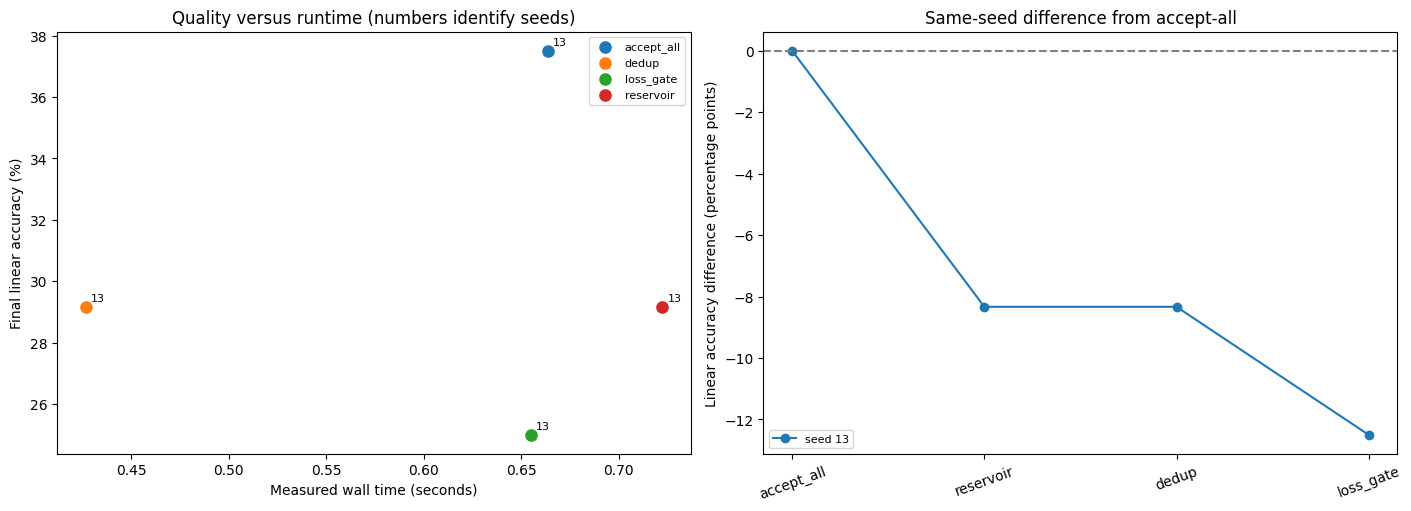

,filter,seed,device,diverged,updates,skipped_batches,train_presentations,wall_seconds,initial_linear_acc,final_linear_acc
0,accept_all,13,cuda,False,35,3,884,0.663570,0.375,0.375000
1,reservoir,13,cuda,False,38,0,2071,0.722363,0.375,0.291667
2,dedup,13,cuda,False,9,29,18,0.426590,0.375,0.291667
3,loss_gate,13,cuda,False,33,5,440,0.654919,0.375,0.250000


In [23]:
valid_summary = summary_df.loc[~summary_df["diverged"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for name, rows in valid_summary.groupby("filter"):
    axes[0].scatter(rows["wall_seconds"], 100 * rows["final_linear_acc"], label=name, s=65)
    for _, result in rows.iterrows():
        axes[0].annotate(
            str(int(result["seed"])),
            (result["wall_seconds"], 100 * result["final_linear_acc"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
axes[0].set(
    xlabel="Measured wall time (seconds)",
    ylabel="Final linear accuracy (%)",
    title="Quality versus runtime (numbers identify seeds)",
)
axes[0].legend(fontsize=8)
reference = valid_summary.loc[valid_summary["filter"] == "accept_all", ["seed", "final_linear_acc"]].rename(
    columns={"final_linear_acc": "accept_all_linear_acc"}
)
paired_df = valid_summary.merge(reference, on="seed", how="inner", validate="many_to_one")
paired_df["delta_vs_accept_all_pp"] = 100 * (paired_df["final_linear_acc"] - paired_df["accept_all_linear_acc"])
for seed, rows in paired_df.groupby("seed"):
    values = rows.set_index("filter").reindex(filter_names)["delta_vs_accept_all_pp"]
    axes[1].plot(range(len(filter_names)), values, marker="o", label=f"seed {seed}")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_xticks(range(len(filter_names)), filter_names, rotation=20)
axes[1].set(ylabel="Linear accuracy difference (percentage points)", title="Same-seed difference from accept-all")
if not paired_df.empty:
    axes[1].legend(fontsize=8)
fig.savefig(output_dir / "quality_cost.png", dpi=150)
paired_df.to_csv(output_dir / "paired_comparison.csv", index=False)
plt.show()
show(
    summary_df[
        [
            "filter",
            "seed",
            "device",
            "diverged",
            "updates",
            "skipped_batches",
            "train_presentations",
            "wall_seconds",
            "initial_linear_acc",
            "final_linear_acc",
        ]
    ]
)

## Reading the results together

1. **Check that learning happened.** A filter with many skipped batches may simply preserve the initial model. That is not evidence that its selections are better.
2. **Compare both quality references.** Improvement over the frozen initialization asks whether adaptation helped. Improvement over accept-all asks whether the filter helped relative to training on every arrival.
3. **Account for work.** Reservoir replay can buy quality with more training presentations. Deduplication and loss gating can reduce presentations while adding scoring overhead. Image counts and measured runtime answer different questions.
4. **Look for repeated evidence.** Expand `seeds` before trusting small differences. Keep the data, probe reservation, model and device fixed when comparing filters.

This notebook does not test whether old conditions are forgotten: its probe is a global scene task. That would require condition-specific evaluation over time. It also does not certify degradation from RankMe or drift alone. These figures help decide whether a larger, controlled follow-up is worth running.

All figures are saved as PNG files beside `summary.csv`, `health.csv`, `selection.csv`, `paired_comparison.csv`, the resolved `config.json`, and per-arm logs. Rerun the notebook from the top after changing settings so the plotted results and configuration agree.
